In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("C:\\Users\\HP\\Downloads\\archive\\ecommerce_customer_data_custom_ratios.csv")

In [24]:
#Data Cleaning
df_clean = df.copy()

df_clean.drop_duplicates(inplace=True)

df_clean['Purchase Date'] = pd.to_datetime(
    df_clean['Purchase Date'],
    dayfirst=True,
    errors='coerce'
)
df_clean['Product Price'] = pd.to_numeric(df_clean['Product Price'], errors='coerce')
df_clean['Total Purchase Amount'] = pd.to_numeric(df_clean['Total Purchase Amount'], errors='coerce')
df_clean['Returns'] = pd.to_numeric(df_clean['Returns'], errors='coerce')

df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)

In [25]:
#Feature Engineering
ref_date = df_clean['Purchase Date'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg(
    Recency=('Purchase Date', lambda x: (ref_date-x.max()).days),
    Frequency=('Purchase Date','count'),
    Monetary=('Total Purchase Amount','sum'),
    Gender=('Gender','first'),
    Age=('Customer Age','first'),
    Returns=('Returns','sum'),
    Churn=('Churn','first')
).reset_index()

In [23]:
#RFM Scoring
rfm['R_Score']=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['F_Score']=pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm['M_Score']=pd.qcut(rfm['Monetary'].rank(method='first'),5,labels=[1,2,3,4,5])

rfm[['R_Score','F_Score','M_Score']]=rfm[['R_Score','F_Score','M_Score']].astype(int)

In [22]:
#Customer Segmentation
def segment(r,f,m):
    if r>=4 and f>=4 and m>=4:
        return "Champions"
    elif r>=3 and f>=3:
        return "Loyal"
    elif r<=2 and f<=2:
        return "Lost"
    else:
        return "Potential"

rfm['Segment']=rfm.apply(lambda x:segment(x.R_Score,x.F_Score,x.M_Score),axis=1)

In [21]:
#Customer Profile
profile=rfm.groupby('Segment').agg({
    'Customer ID':'count',
    'Monetary':'mean',
    'Frequency':'mean',
    'Recency':'mean'
})

print(profile)

           Customer ID      Monetary  Frequency     Recency
Segment                                                    
Champions         8739  21785.056299   7.647557   61.307243
Lost             11115   7578.839586   2.775169  564.272245
Loyal            12354  15355.158329   5.871782  128.992391
Potential        17465  12426.375494   4.568108  262.500429


In [13]:
#Data Visualisation

✓ Visualization 2 saved: 02_purchase_patterns.png


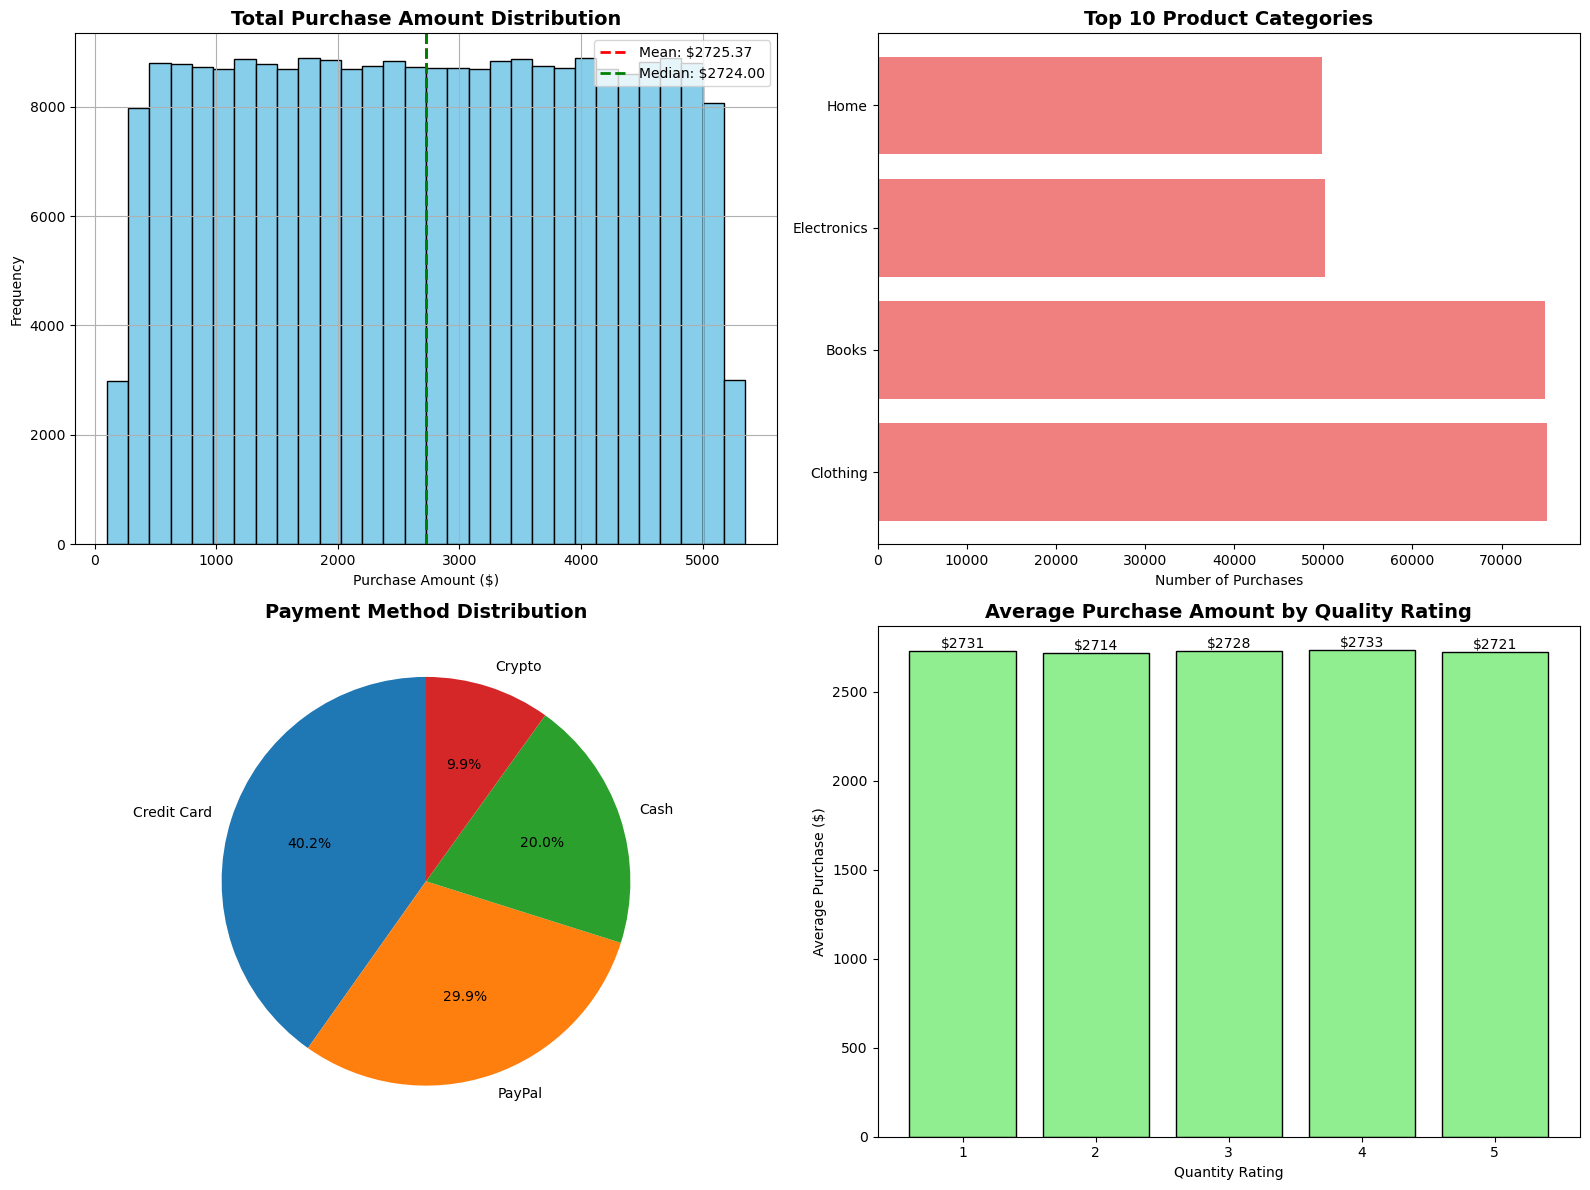

In [20]:
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---------------- Chart 1 ----------------
ax1 = axes[0, 0]

df_clean['Total Purchase Amount'].hist(
    bins=30,
    ax=ax1,
    color='skyblue',
    edgecolor='black'
)

ax1.set_title('Total Purchase Amount Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Purchase Amount ($)')
ax1.set_ylabel('Frequency')

mean_purchase = df_clean['Total Purchase Amount'].mean()
median_purchase = df_clean['Total Purchase Amount'].median()

ax1.axvline(mean_purchase, color='red', linestyle='--',
            linewidth=2, label=f'Mean: ${mean_purchase:.2f}')

ax1.axvline(median_purchase, color='green', linestyle='--',
            linewidth=2, label=f'Median: ${median_purchase:.2f}')

ax1.legend()

# ---------------- Chart 2 ----------------
ax2 = axes[0, 1]

top_categories = df_clean['Product Category'].value_counts().head(10)

ax2.barh(
    top_categories.index,
    top_categories.values,
    color='lightcoral'
)

ax2.set_title('Top 10 Product Categories', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Purchases')

# ---------------- Chart 3 ----------------
ax3 = axes[1, 0]

payment_dist = df_clean['Payment Method'].value_counts()

ax3.pie(
    payment_dist.values,
    labels=payment_dist.index,
    autopct='%1.1f%%',
    startangle=90
)

ax3.set_title('Payment Method Distribution', fontsize=14, fontweight='bold')

# ---------------- Chart 4 ----------------
ax4 = axes[1, 1]

quality_dist = df_clean.groupby('Quantity')['Total Purchase Amount'].mean()

ax4.bar(
    quality_dist.index.astype(str),
    quality_dist.values,
    color='lightgreen',
    edgecolor='black'
)

ax4.set_title('Average Purchase Amount by Quality Rating', fontsize=14, fontweight='bold')
ax4.set_xlabel('Quantity Rating')
ax4.set_ylabel('Average Purchase ($)')

for i, value in enumerate(quality_dist.values):
    ax4.text(i, value, f'${value:.0f}', ha='center', va='bottom')

plt.tight_layout()

# Save figure
plt.savefig('02_purchase_patterns.png', dpi=300, bbox_inches='tight')

print("✓ Visualization 2 saved: 02_purchase_patterns.png")

plt.show()

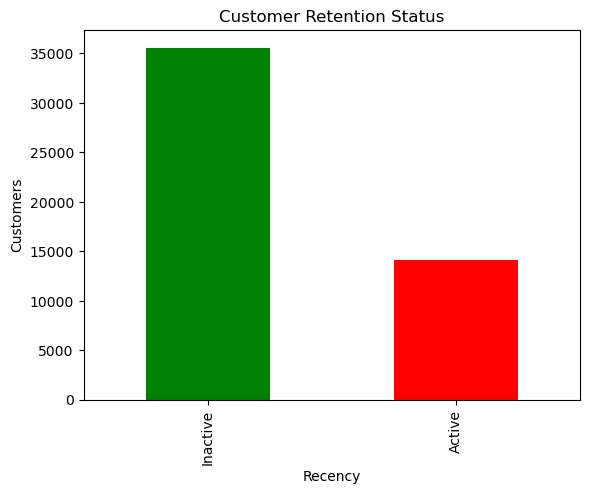

In [27]:
# Rentation Trend
activity = rfm['Recency'].apply(lambda x:'Active' if x<=90 else 'Inactive')

activity.value_counts().plot(kind='bar',color=['green','red'])

plt.title("Customer Retention Status")
plt.ylabel("Customers")
plt.show()